 <h1 style="font-size:18px;color: red;"> 📊 Genel Bilgiler </h1>

- **Toplam Gözlem (Satır):** 58 645

- **Toplam Değişken (Sütun):** 13

> Veri, bireylerin kredi (loan) başvurularına ilişkin demografik ve finansal özellikleri ile kredi sonucunu (onay/ret) içeriyor.

---

<h2 style="font-size:18px;color: red;">🧩 Sütunların Anlamları ve Özellikleri</h2>

---

| Sütun Adı                          | Veri Tipi | Boş Değer | Benzersiz Değer | Açıklama & Örnekler                                                                                    |
| ---------------------------------- | --------- | --------- | --------------- | ------------------------------------------------------------------------------------------------------ |
| **id**                             | int       | 0         | 58 645          | Her başvuruya ait benzersiz kimlik numarası.                                                           |
| **person\_age**                    | int       | 0         | 53              | Başvuranın yaşı (örn: 37, 22, 29).                                                                     |
| **person\_income**                 | int       | 0         | 2 641           | Yıllık gelir (USD cinsinden) – örn: 35 000, 56 000.                                                    |
| **person\_home\_ownership**        | object    | 0         | 4               | Konut durumu: `RENT`, `OWN`, `MORTGAGE`, `OTHER`.                                                      |
| **person\_emp\_length**            | int       | 0         | 36              | İşte çalışma süresi (yıl). Örn: 0, 6, 8.                                                               |
| **loan\_intent**                   | object    | 0         | 6               | Kredinin amacı: `EDUCATION`, `MEDICAL`, `PERSONAL`, `VENTURE`, `HOMEIMPROVEMENT`, `DEBTCONSOLIDATION`. |
| **loan\_grade**                    | object    | 0         | 7               | Kredi skoru sınıfı: `A` (en iyi)–`G` (en düşük).                                                       |
| **loan\_amnt**                     | int       | 0         | 545             | Talep edilen kredi miktarı (USD).                                                                      |
| **loan\_int\_rate**                | float     | 0         | 362             | Kredi faiz oranı (%). Örn: 11.49, 13.35, 8.9.                                                          |
| **loan\_percent\_income**          | float     | 0         | 61              | Kredinin, başvuranın gelirine oranı. (Örn: 0.17 = gelirinin %17’si).                                   |
| **cb\_person\_default\_on\_file**  | object    | 0         | 2               | Kredi bürosu kaydında geçmişte temerrüt (ödenmemiş borç) olup olmadığı: `Y` veya `N`.                  |
| **cb\_person\_cred\_hist\_length** | int       | 0         | 29              | Kredi geçmişi uzunluğu (yıl).                                                                          |
| **loan\_status**                   | int       | 0         | 2               | Hedef değişken: 1 = Krediyi ödemede sorun/temerrüt, 0 = Sorunsuz ödeyen.                               |

---

<h2 style="font-size:18px;color: red;"> 🔎 Değişken Türleri </h2>

- **Sayısal (int/float):** id, person_age, person_income, person_emp_length, loan_amnt, loan_int_rate, loan_percent_income, cb_person_cred_hist_length, loan_status

- **Kategorik (object):** person_home_ownership, loan_intent, loan_grade, cb_person_default_on_file

---

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df_ = pd.read_csv('/kaggle/input/loang-db/loangdb.csv')
df = df_.copy()

In [2]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2,MEDICAL,A,6000,6.92,0.10,N,3,0


<h2 style="font-size:30px;color: red;"> Genel Bakış</h2>

In [3]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1], numeric_only=True ).T)

check_df(df)

##################### Shape #####################
(58645, 13)
##################### Types #####################
id                              int64
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length               int64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object
##################### NA #####################
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_def

In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and str(dataframe[col].dtypes) in ["int32", "float32", "int64", "float64"]]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and str(dataframe[col].dtypes) in ["category", "object"]]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int64", "float64"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [5]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print('Categorial Columns:', cat_cols)
print('-------------------------')
print('Numeric Columns:', num_cols)
print('-------------------------')
print('Categorial but Cardinal Columns:',cat_but_car)

Observations: 58645
Variables: 13
cat_cols: 5
num_cols: 8
cat_but_car: 0
num_but_cat: 1
Categorial Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']
-------------------------
Numeric Columns: ['id', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
-------------------------
Categorial but Cardinal Columns: []


<h2 style="font-size:30px;color: red;">Aykırı Değer Analizi</h2>

In [6]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [7]:
for col in num_cols:
    print(col, check_outlier(df, col))

id False
person_age True
person_income True
person_emp_length True
loan_amnt False
loan_int_rate False
loan_percent_income True
cb_person_cred_hist_length False


<h2 style="font-size:30px;color: red;"> Hedef Değişken Analizi </h2>

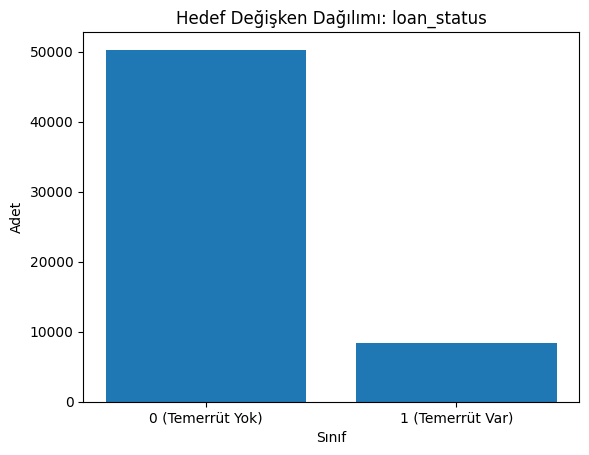

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2) Hedef değişken (loan_status) dağılımı
target = "loan_status"
class_counts = df[target].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)
target_dist = pd.DataFrame({
    "Sınıf": class_counts.index,
    "Adet": class_counts.values,
    "Yüzde(%)": class_pct.values
})

# Bar grafik (tek grafik)
plt.figure()
plt.bar(["0 (Temerrüt Yok)", "1 (Temerrüt Var)"], class_counts.values)
plt.title("Hedef Değişken Dağılımı: loan_status")
plt.xlabel("Sınıf")
plt.ylabel("Adet")
plt.show()

<h2 style="font-size:30px;color: red;"> Korelasyon Analizi</h2>

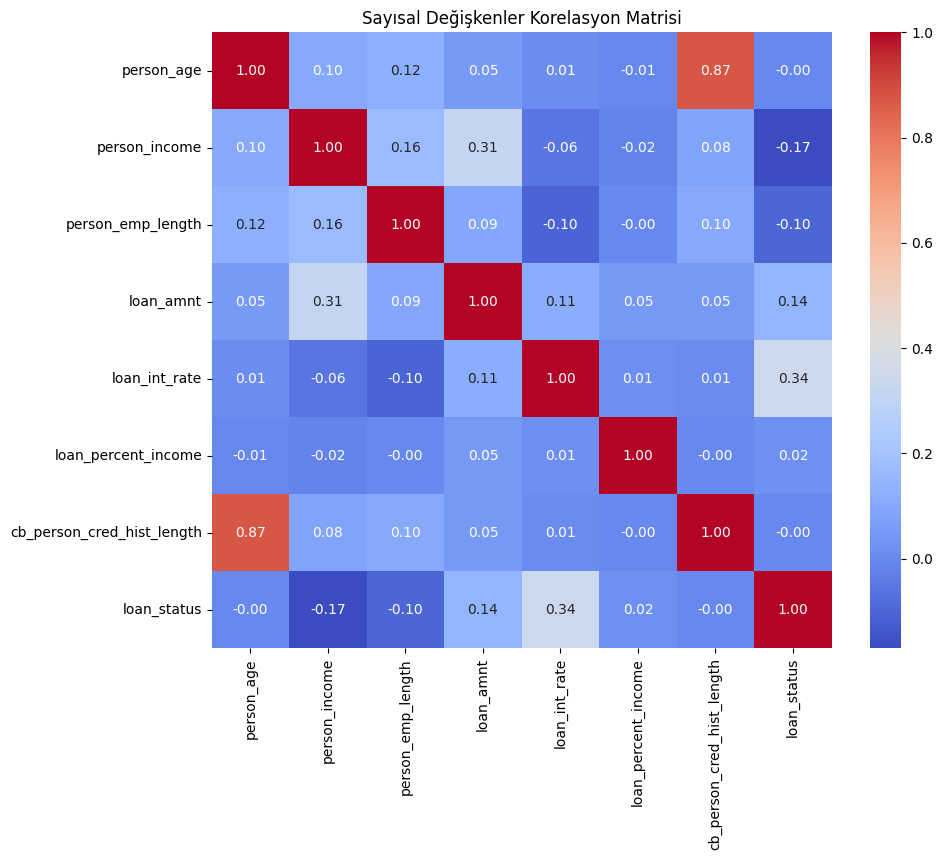

In [9]:
import seaborn as sns

# Korelasyon matrisi (loan_status dahil sayısallar)
corr = df.corr(numeric_only=True)

# loan_status dahil gösterim ama id'yi hariç tut
corr = corr.drop("id", axis=0).drop("id", axis=1)

# Görsel ısı haritası
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.show()


| Değişkenler                                      | Korelasyon (≈) | Yorum                                                                                     |
| ------------------------------------------------ | -------------- | ----------------------------------------------------------------------------------------- |
| **person\_age ↔ cb\_person\_cred\_hist\_length** | **0.87**       | Çok güçlü pozitif. Mantıklı: Yaş arttıkça kredi geçmişi süresi de uzuyor.                 |
| **person\_income ↔ loan\_amnt**                  | **0.31**       | Orta pozitif. Daha yüksek gelirli kişiler daha yüksek miktarda kredi almış.               |
| **loan\_int\_rate ↔ loan\_status**               | **0.34**       | Hedefle en belirgin pozitif ilişki. Faiz oranı arttıkça temerrüt olasılığı artıyor.       |
| **person\_income ↔ loan\_status**                | **–0.17**      | Hafif negatif. Gelir yükseldikçe temerrüt riski azalıyor.                                 |
| **person\_emp\_length ↔ loan\_status**           | **–0.10**      | Hafif negatif. İşte daha uzun süre çalışanların temerrüt riski biraz daha düşük.          |
| **loan\_amnt ↔ loan\_status**                    | **0.14**       | Düşük-orta pozitif. Daha büyük kredi tutarı biraz daha fazla temerrüt riski ile ilişkili. |

<h2 style="font-size:30px;color: red;" >Sayısal Değişken Analizi</h2>

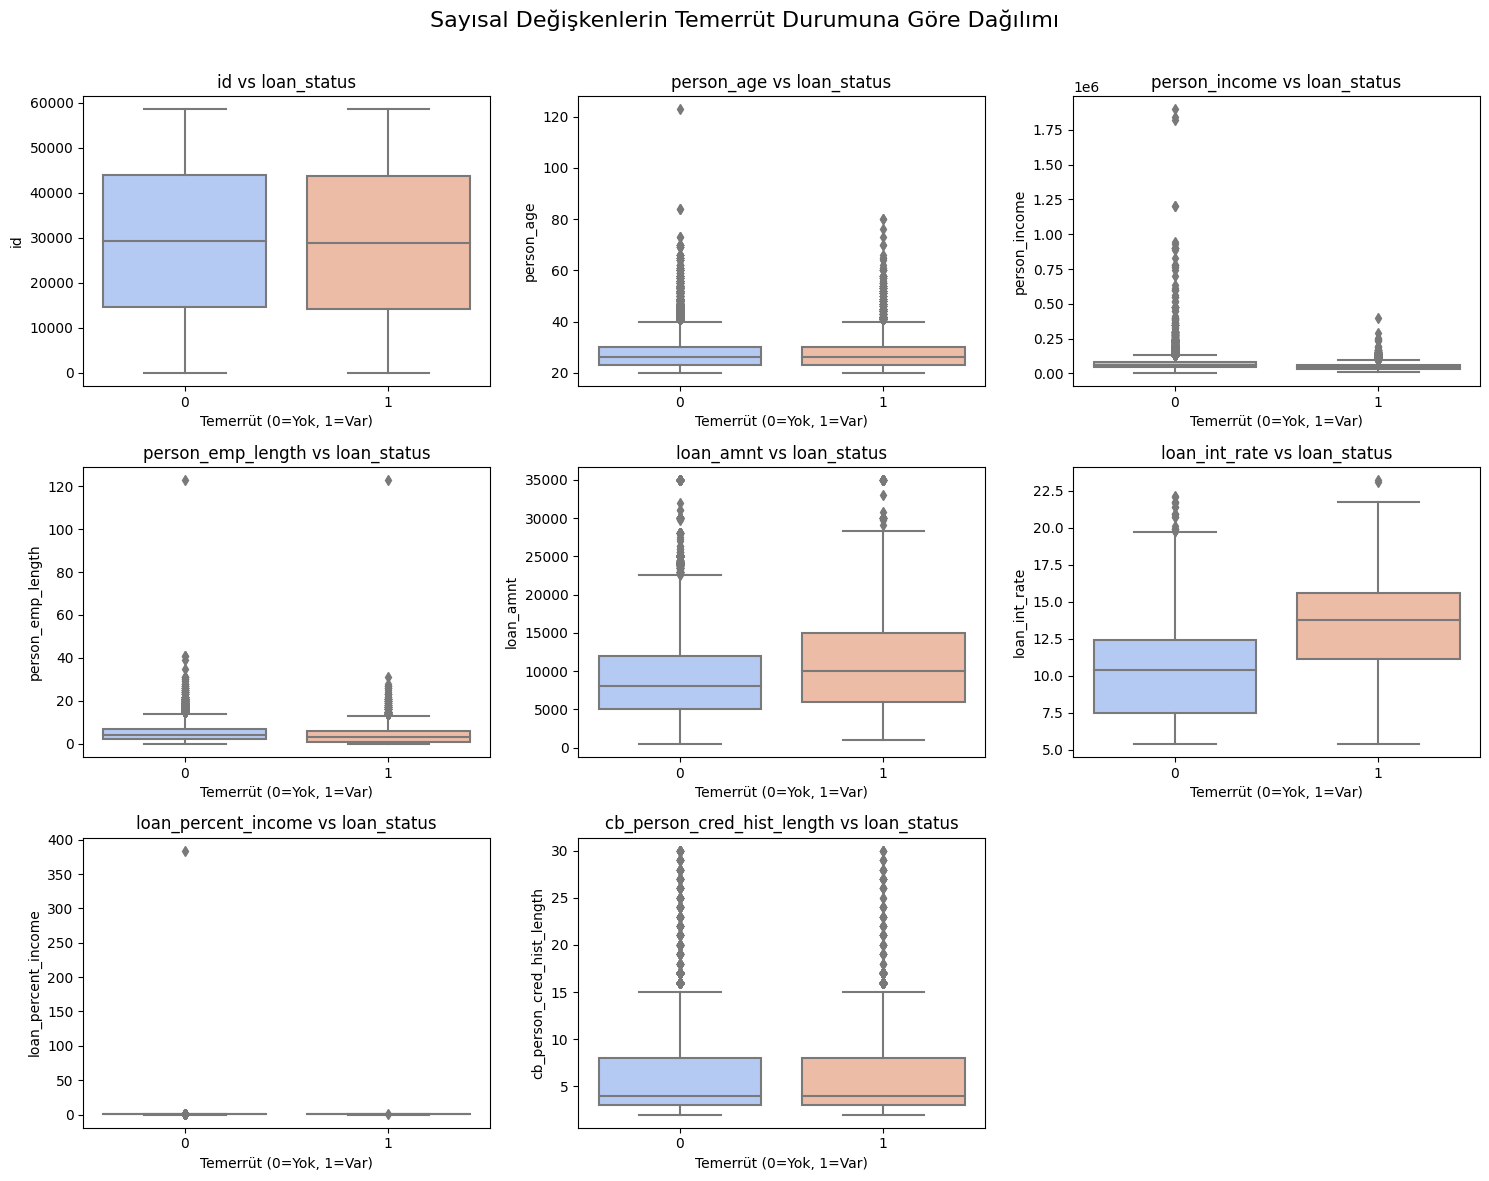

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hedef değişken ile sayısalların ilişkisini tek bir gridde kutu grafikleri olarak gösterelim
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="loan_status", y=col, data=df, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{col} vs loan_status")
    axes[i].set_xlabel("Temerrüt (0=Yok, 1=Var)")
    axes[i].set_ylabel(col)

# Boş kalan subplotları kapatalım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Sayısal Değişkenlerin Temerrüt Durumuna Göre Dağılımı", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- loan_int_rate: Temerrüt edenlerin faiz oranı belirgin biçimde daha yüksek—en güçlü ayrım burada.

- person_income: Temerrüt sınıfında medyan gelir net biçimde daha düşük.

- cb_person_cred_hist_length: Kredi geçmişi süresi kısa olanlarda temerrüt daha fazla.

- person_emp_length: İşte çalışma süresi kısa olanların kutusu yukarıda yoğun—daha fazla risk.

- loan_amnt ve loan_percent_income: Temerrüt sınıfı hafifçe yukarı kaymış; yüksek miktar ve gelir oranı riski artırıyor.

- person_age: İki sınıf arasında fark minimal; yaş çok belirleyici değil.

<h2 style="font-size:30px;color: red;"> Kategorik Değişken Analizi </h2>

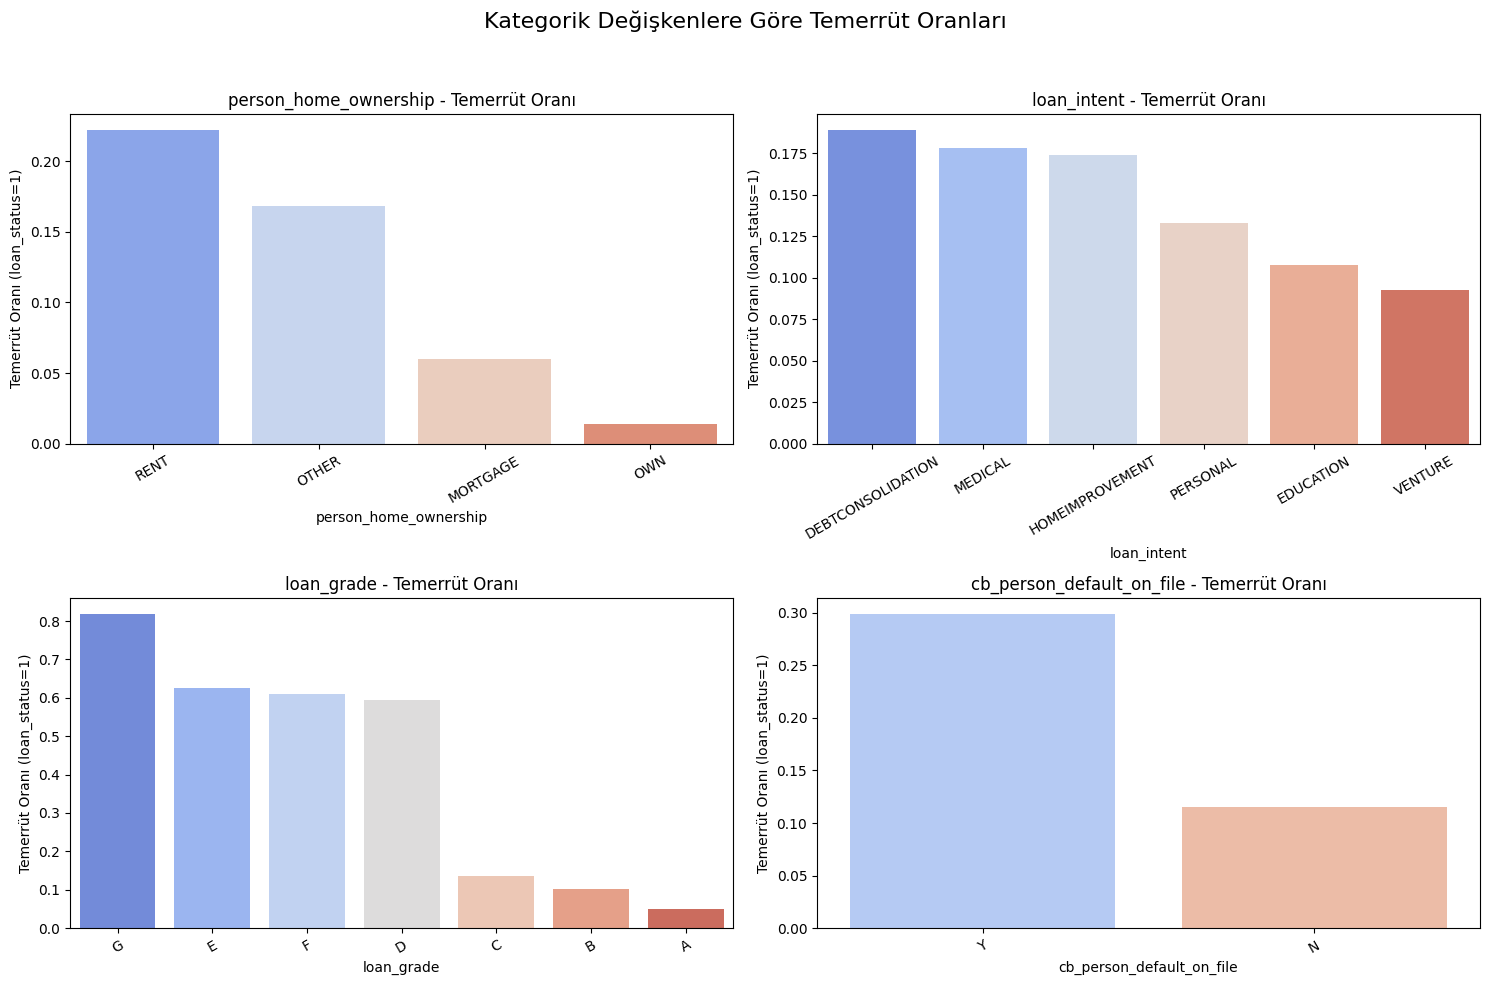

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Kategorik kolonlar
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Her kategori için temerrüt oranını hesapla
    temp = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    sns.barplot(x=temp.index, y=temp.values, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{col} - Temerrüt Oranı")
    axes[i].set_ylabel("Temerrüt Oranı (loan_status=1)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle("Kategorik Değişkenlere Göre Temerrüt Oranları", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



### 1️⃣ person_home_ownership – Konut Durumu

- RENT (Kiracı): %22 ile en yüksek risk.

- OTHER: %17 civarı (görece az ama yüksek).

- MORTGAGE (İpotek): Yaklaşık %6.

- OWN (Kendi Evi): Sadece %1.4 – en güvenli grup.

**Kiracılar ve belirsiz konut statüsü (OTHER) temerrüte çok daha yatkın.**

### 2️⃣ loan_intent – Kredi Amacı

- DEBTCONSOLIDATION (Borç Birleştirme): En yüksek temerrüt oranı.

- PERSONAL, MEDICAL: Orta seviye risk.

- EDUCATION, VENTURE, HOMEIMPROVEMENT: Daha düşük oranlar.

**Borç kapatma veya kişisel harcamalar için kredi çekenlerin riski daha yüksek.**

### 3️⃣ loan_grade – Kredi Notu

- G: Açık ara en riskli sınıf.

- A’dan G’ye doğru temerrüt oranı kademeli artıyor.(Örneğin A ~%2, G >%35.)

**Kredi notu (grade) en güçlü kategorik prediktörlerden biri.**

### 4️⃣ cb_person_default_on_file – Geçmiş Temerrüt Kaydı

- Y (Evet): Temerrüt oranı bariz yüksek (yaklaşık %35).

- N (Hayır): Çok daha düşük (~%10).

**Geçmişte temerrütü olanların yeniden temerrüt etme ihtimali doğal olarak yüksek.**

### Özet

> Kredi notu (loan_grade) ve geçmiş temerrüt kaydı (cb_person_default_on_file), hedef değişkenle en güçlü ilişkiye sahip kategorik özellikler.

> Konut durumu (home_ownership) de önemli; özellikle kiracı olanların riski belirgin.

> Kredi amacı (loan_intent) de ayrım gücüne sahip, özellikle “borç birleştirme” amaçlı krediler riskli.

<h2 style="font-size:45px;color: red;"> Genel Özet </h2>
    
- **En kritik göstergeler:**
> Yüksek faiz, düşük gelir, kısa kredi geçmişi, düşük kredi notu, geçmiş temerrüt kaydı, kiracı olmak.

Bu özellikler birlikte değerlendirildiğinde, temerrüt riskini erken tahmin etmek için güçlü bir model kurulabilir.

- **Hedefe Yönelik Öneri veya İçgörü:

>Modellemede özellikle loan_int_rate, loan_grade, cb_person_default_on_file, person_income, cb_person_cred_hist_length değişkenlerine yüksek önem verilmelidir.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = df[["loan_int_rate","person_income","cb_person_cred_hist_length",
        "person_emp_length","loan_amnt","loan_percent_income",
        "loan_grade","cb_person_default_on_file",
        "person_home_ownership","loan_intent"]]
y = df["loan_status"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only numeric columns (optional: all numeric after get_dummies)
scaler = StandardScaler()
num_cols = ["loan_int_rate","person_income","cb_person_cred_hist_length",
            "person_emp_length","loan_amnt","loan_percent_income"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Base Logistic Regression
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train, y_train)

# Predictions & metrics
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.97      0.83      0.89     10059
           1       0.45      0.84      0.59      1670

    accuracy                           0.83     11729
   macro avg       0.71      0.84      0.74     11729
weighted avg       0.90      0.83      0.85     11729

ROC-AUC: 0.9016467512335901


In [13]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Özellik ve hedef
X = df[["loan_int_rate","person_income","cb_person_cred_hist_length",
        "person_emp_length","loan_amnt","loan_percent_income",
        "loan_grade","cb_person_default_on_file",
        "person_home_ownership","loan_intent"]]
y = df["loan_status"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# (Opsiyonel) yalnızca sayısalları scale et
num_cols = ["loan_int_rate","person_income","cb_person_cred_hist_length",
            "person_emp_length","loan_amnt","loan_percent_income"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# LightGBM model
lgbm = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    is_unbalance=True,          #  dengesiz veri için
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train, y_train)

# Tahmin
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


[LightGBM] [Info] Number of positive: 6680, number of negative: 40236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 838
[LightGBM] [Info] Number of data points in the train set: 46916, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142382 -> initscore=-1.795644
[LightGBM] [Info] Start training from score -1.795644
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     10059
           1       0.72      0.84      0.77      1670

    accuracy                           0.93     11729
   macro avg       0.84      0.89      0.87     11729
weighted avg       0.94      0.93      0.93     11729

ROC-AUC: 0.9573801398098523


-> Yapıalcaklar
- Feature üretme ve Feature importance
- hiperparametre optimizasyonu
